# Random Forest Training

Train a stronger pixel-wise Random Forest baseline with richer spectral and texture features, then visualize one held-out test prediction.

In [31]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio

from scipy.ndimage import uniform_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "samples_generated"
if not DATA_DIR.exists():
    DATA_DIR = ROOT / "data" / "samples_prepared"

MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {1: "Greenery", 2: "Sand", 3: "Water", 4: "Cement"}
CLASS_IDS = list(CLASS_NAMES)
TARGET_NAMES = [CLASS_NAMES[i] for i in CLASS_IDS]
COLORS = np.array([
    [0, 0, 0],
    [0, 100, 0],
    [184, 134, 11],
    [0, 0, 139],
    [105, 105, 105],
], dtype=np.uint8)

RNG = np.random.default_rng(42)
DATA_DIR

PosixPath('/mnt/windows_data/CUFE/Fourth Year/Second Semester/Satellite_Imagery/Project_v2/data/samples_generated')

In [32]:
def load_sample(row):
    with rio.open(row.spectral_path) as src:
        spectral = src.read().astype("float32")

    with rio.open(row.mask_path) as src:
        mask = src.read(1).astype("uint8")

    return spectral, mask


def norm_diff(a, b):
    return (a - b) / (a + b + 1e-6)


def local_stats(image, size=5):
    mean = uniform_filter(image, size=size, mode="nearest")
    sq_mean = uniform_filter(image * image, size=size, mode="nearest")
    std = np.sqrt(np.clip(sq_mean - mean * mean, 0, None))
    return mean, std


def add_features(spectral):
    bands = np.moveaxis(spectral, 0, -1)

    b2 = bands[..., 1]
    b3 = bands[..., 2]
    b4 = bands[..., 3]
    b8 = bands[..., 7]
    b11 = bands[..., 10]

    ndvi = norm_diff(b8, b4)
    ndwi = norm_diff(b3, b8)
    mndwi = norm_diff(b3, b11)
    ndbi = norm_diff(b11, b8)
    bsi = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + 1e-6)

    features = [
        bands,
        ndvi[..., None],
        ndwi[..., None],
        mndwi[..., None],
        ndbi[..., None],
        bsi[..., None],
    ]

    for layer in [ndvi, mndwi, ndbi, b11]:
        mean, std = local_stats(layer, size=5)
        features.extend([mean[..., None], std[..., None]])

    return np.dstack(features).astype("float32")


def rgb_preview(spectral):
    rgb = np.moveaxis(spectral[[3, 2, 1]], 0, -1)
    low = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    high = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - low) / (high - low + 1e-6), 0, 1)


def colorize(mask):
    return COLORS[mask]


def predict_scene(model, spectral):
    features = add_features(spectral)
    height, width, depth = features.shape
    pred = model.predict(features.reshape(-1, depth))
    return pred.reshape(height, width).astype("uint8")


def build_training_set(frame, max_per_class_per_image=1500):
    xs, ys = [], []

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample(row)
        features = add_features(spectral)
        flat_features = features.reshape(-1, features.shape[-1])
        labels = mask.reshape(-1)

        for cls in CLASS_IDS:
            idx = np.flatnonzero(labels == cls)
            if len(idx) == 0:
                continue

            take = min(max_per_class_per_image, len(idx))
            pick = RNG.choice(idx, size=take, replace=False)
            xs.append(flat_features[pick])
            ys.append(np.full(take, cls, dtype=np.uint8))

    return np.vstack(xs), np.concatenate(ys)

In [33]:
samples = []

for spectral_path in sorted(DATA_DIR.glob("*/*_Spectral.tif")):
    sample = spectral_path.parent.name
    mask_path = spectral_path.with_name(f"{sample}_Mask.tif")
    if mask_path.exists():
        samples.append({
            "sample": sample,
            "spectral_path": spectral_path,
            "mask_path": mask_path,
        })

samples = pd.DataFrame(samples)
samples

,sample,spectral_path,mask_path
0,6thOfOctoberCity,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
1,AbuSimbel,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
2,AinSokhna,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
3,AlKhargaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
4,Alexandria,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
5,Asyut,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
6,BahariyaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
7,BeniSuef,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
8,CairoUniv,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
9,DakhlaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...


In [34]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(samples, groups=samples["sample"]))

train_df = samples.iloc[train_idx].reset_index(drop=True)
test_df = samples.iloc[test_idx].reset_index(drop=True)

print(f"train scenes: {len(train_df)}")
print(train_df["sample"].tolist())
print()
print(f"test scenes: {len(test_df)}")
print(test_df["sample"].tolist())

train scenes: 32
['6thOfOctoberCity', 'AbuSimbel', 'AinSokhna', 'Asyut', 'BeniSuef', 'DakhlaOasis', 'EastPortSaidPort', 'ElAlamein', 'ElGouna', 'Faiyum', 'Farafra', 'GreatPyramidOfGiza', 'HawaraFayoum', 'Hurghada', 'IconicTower', 'Ismailia', 'KarnakLuxor', 'KomOmbo', 'LakeBardawil', 'LakeQarun', 'MarsaAlam', 'MarsaMatrouh', 'Minya', 'NewAlamein', 'NewCairo', 'PhilaeAswan', 'Qena', 'RashidRosetta', 'SiwaOasis', 'SuezPort', 'ToshkaLakes', 'WadiElNatrun']

test scenes: 11
['AlKhargaOasis', 'Alexandria', 'BahariyaOasis', 'CairoUniv', 'ElArish', 'LakeBurullus', 'LakeManzala', 'RasMuhammadNationalPark', 'SaintCatherine', 'SharqElOwainat', 'Sohag']


In [35]:
X_train, y_train = build_training_set(train_df, max_per_class_per_image=1500)

print(f"training pixels: {len(y_train):,}")
print(f"feature count: {X_train.shape[1]}")

pd.Series(y_train).map(CLASS_NAMES).value_counts().rename_axis("class").to_frame("pixels")

training pixels: 129,590
feature count: 25


,pixels
class,
Sand,42119
Cement,34084
Water,27371
Greenery,26016


In [36]:
model = RandomForestClassifier(
    n_estimators=60,
    max_depth=24,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)

model.fit(X_train, y_train)

model_path = MODEL_DIR / "random_forest_baseline.joblib"
joblib.dump(model, model_path)
model_path

PosixPath('/mnt/windows_data/CUFE/Fourth Year/Second Semester/Satellite_Imagery/Project_v2/outputs/models/random_forest_baseline.joblib')

In [37]:
cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)

all_y_true = []
all_y_pred = []

for row in test_df.itertuples(index=False):
    spectral, mask = load_sample(row)
    pred = predict_scene(model, spectral)

    all_y_true.extend(mask.reshape(-1))
    all_y_pred.extend(pred.reshape(-1))

    valid = mask > 0
    cm += confusion_matrix(mask[valid], pred[valid], labels=CLASS_IDS)

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
valid_indices = np.isin(all_y_true, CLASS_IDS)

intersection = np.diag(cm)
union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
iou = intersection / np.maximum(union, 1)

metrics = pd.DataFrame({
    "class_id": CLASS_IDS,
    "class_name": TARGET_NAMES,
    "IoU": iou,
    "support": cm.sum(axis=1),
}).sort_values("class_id")

print(f"mIoU: {metrics['IoU'].mean():.3f}")
display(metrics)
print()
print("Classification report")
print(classification_report(
    all_y_true[valid_indices],
    all_y_pred[valid_indices],
    labels=CLASS_IDS,
    target_names=TARGET_NAMES,
    zero_division=0,
))

mIoU: 0.783


,class_id,class_name,IoU,support
0,1,Greenery,0.722047,82536
1,2,Sand,0.798837,315047
2,3,Water,0.962734,194407
3,4,Cement,0.646602,203588



Classification report
              precision    recall  f1-score   support

    Greenery       0.78      0.90      0.84     82536
        Sand       0.87      0.90      0.89    315047
       Water       0.98      0.98      0.98    194407
      Cement       0.84      0.74      0.79    203588

    accuracy                           0.88    795578
   macro avg       0.87      0.88      0.87    795578
weighted avg       0.88      0.88      0.88    795578



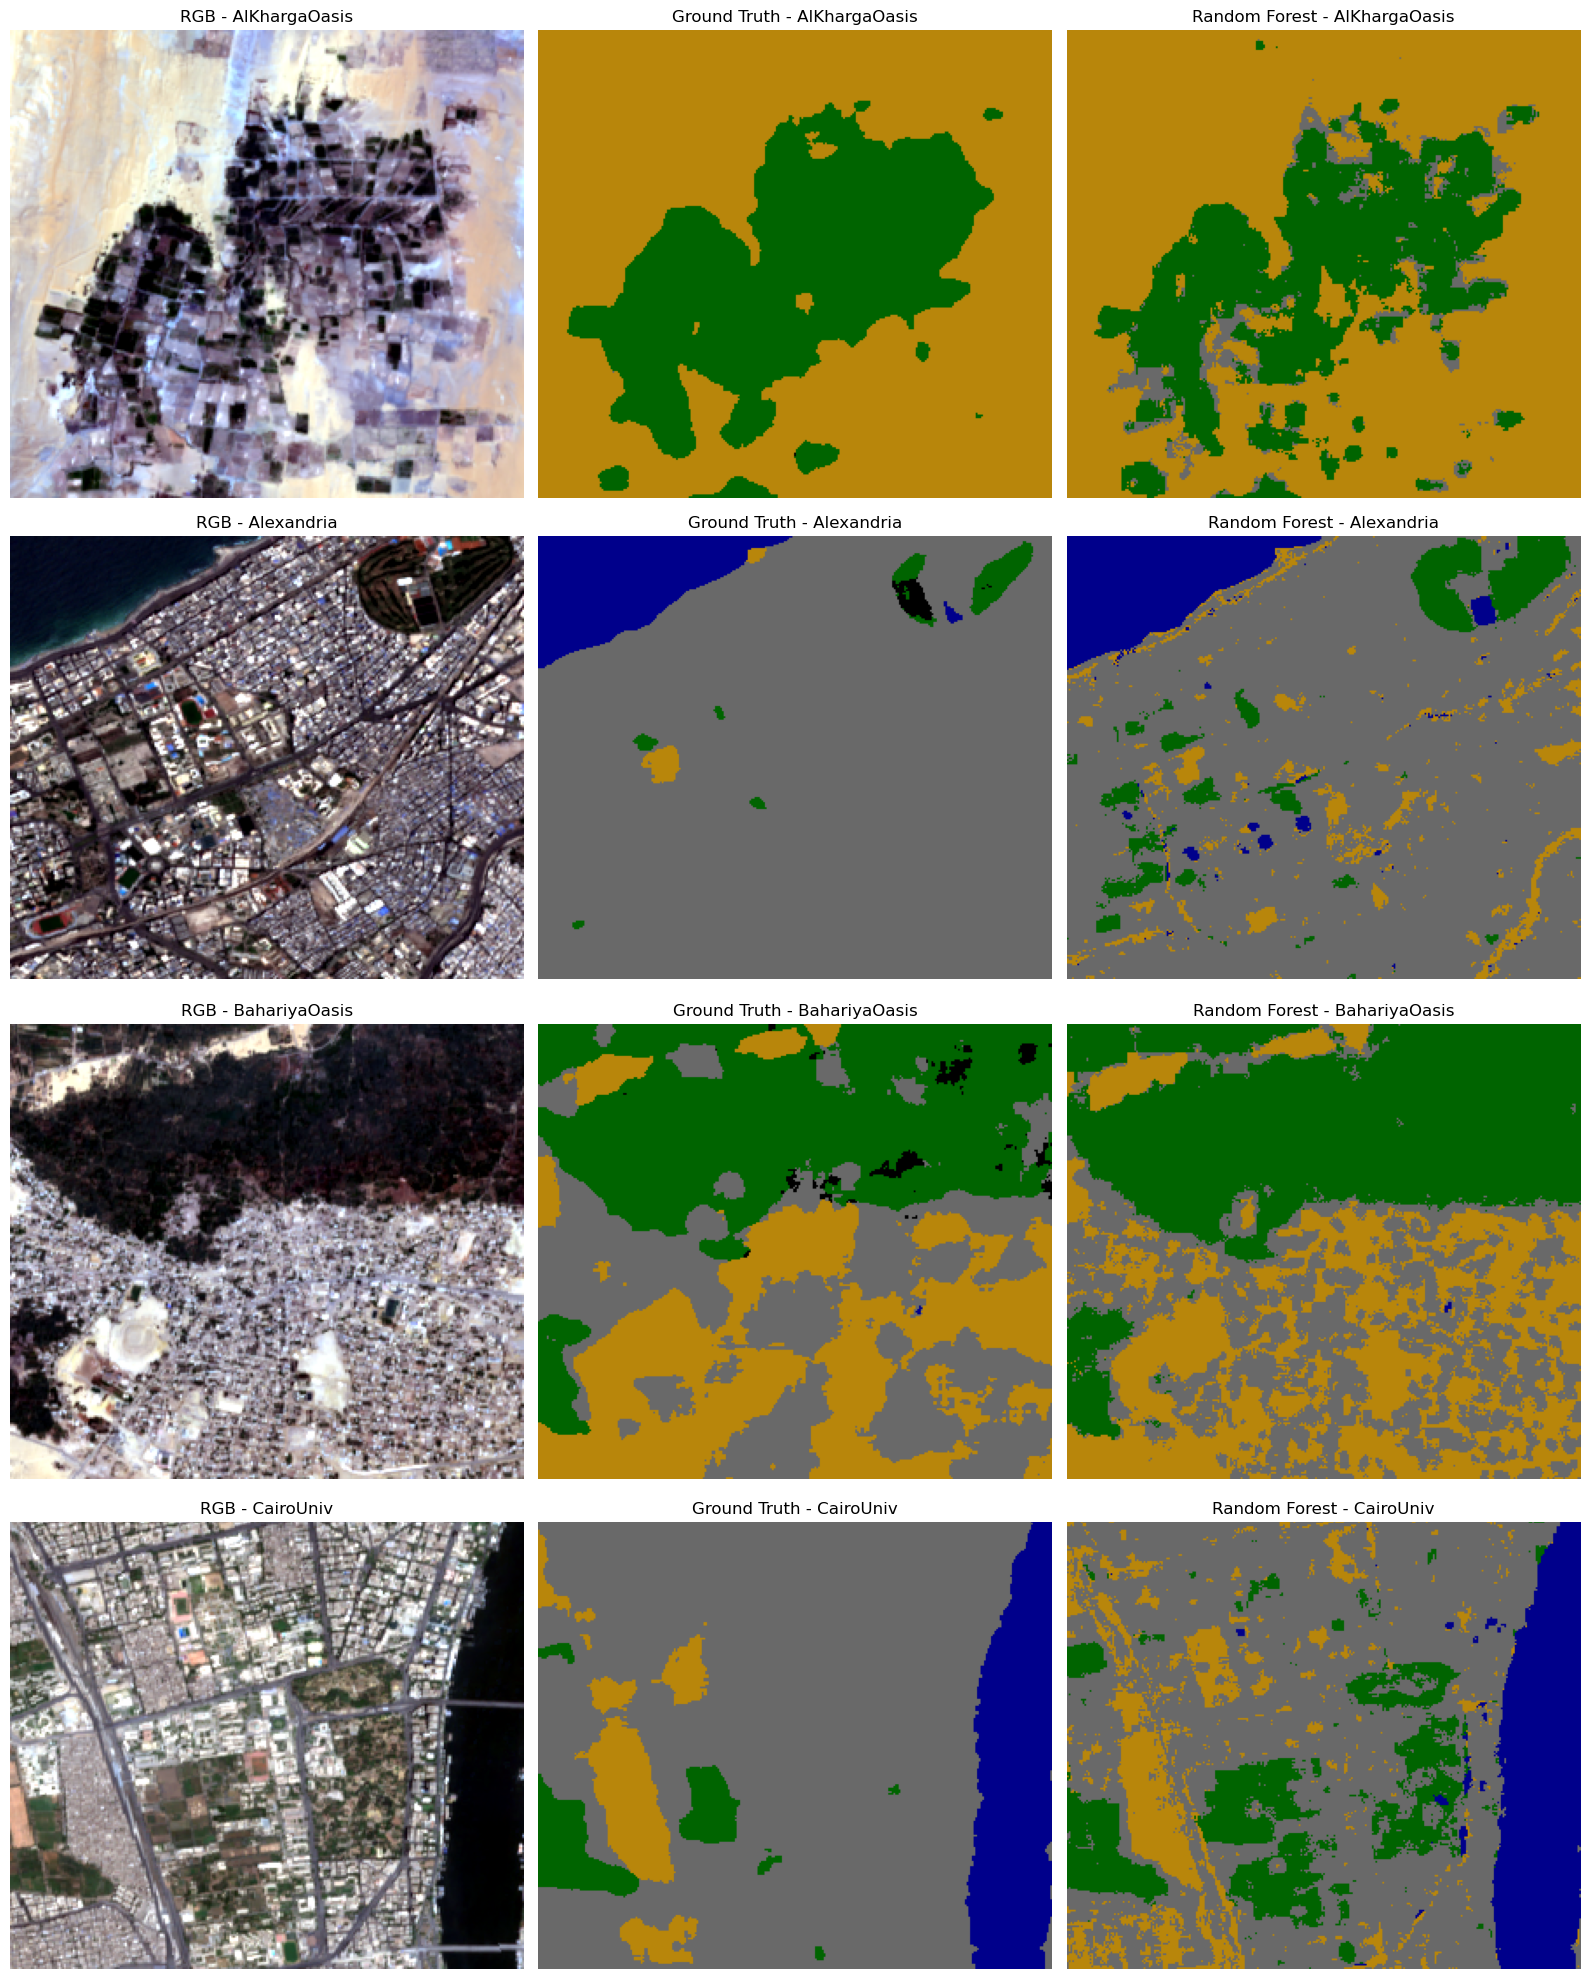

In [38]:
n_show = min(4, len(test_df))
rows = test_df.iloc[:n_show]

fig, ax = plt.subplots(n_show, 3, figsize=(16, 5 * n_show))
if n_show == 1:
    ax = np.array([ax])

for i, row in enumerate(rows.itertuples(index=False)):
    spectral, mask = load_sample(row)
    pred = predict_scene(model, spectral)

    ax[i, 0].imshow(rgb_preview(spectral))
    ax[i, 0].set_title(f"RGB - {row.sample}")

    ax[i, 1].imshow(colorize(mask))
    ax[i, 1].set_title(f"Ground Truth - {row.sample}")

    ax[i, 2].imshow(colorize(pred))
    ax[i, 2].set_title(f"Random Forest - {row.sample}")

    for a in ax[i]:
        a.axis("off")

plt.tight_layout()
plt.show()